# Practice 3 Guillem Moreno Garcia
## Objectives:
1. Learn to deal with dates
2. Deal with *colinearity*
3. Do a simple Linear regression

Aplication:
Data basse: Data set from the UCI Machine Learning Repository (http://archive.ics.uci.edu/ml)

Appliances energy prediction Data Set: http://archive.ics.uci.edu/ml/datasets/Appliances+energy+prediction#
Predict **Appliances energy consumption in Watts/hour**.
Database: Wine quality, http://archive.ics.uci.edu/ml/datasets/Wine+Quality
Predict quality (score between 0 and 10)

In [36]:
import pandas as pd
import os 
import matplotlib.pyplot as plt
import numpy as np
import sklearn
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge

In [37]:
File = "energydata_complete.csv"
Filename = os.path.join(os.getcwd(),'Data',File)
print(f'Filename with path: \n {Filename}')

Filename with path: 
 c:\mlearn-lab\ThirdPractice\Data\energydata_complete.csv


In [38]:
Data = pd.read_csv(Filename)
Data.head().T

,0,1,2,3,4
date,2016-01-11 17:00:00,2016-01-11 17:10:00,2016-01-11 17:20:00,2016-01-11 17:30:00,2016-01-11 17:40:00
Appliances,60,60,50,50,60
lights,30,30,30,40,40
T1,19.89,19.89,19.89,19.89,19.89
RH_1,47.596667,46.693333,46.3,46.066667,46.333333
T2,19.2,19.2,19.2,19.2,19.2
RH_2,44.79,44.7225,44.626667,44.59,44.53
T3,19.79,19.79,19.79,19.79,19.79
RH_3,44.73,44.79,44.933333,45.0,45.0
T4,19.0,19.0,18.926667,18.89,18.89


## First we clean the date feature into something usefull

In [39]:
pd.to_datetime(Data['date'])

0       2016-01-11 17:00:00
1       2016-01-11 17:10:00
2       2016-01-11 17:20:00
3       2016-01-11 17:30:00
4       2016-01-11 17:40:00
                ...        
19730   2016-05-27 17:20:00
19731   2016-05-27 17:30:00
19732   2016-05-27 17:40:00
19733   2016-05-27 17:50:00
19734   2016-05-27 18:00:00
Name: date, Length: 19735, dtype: datetime64[ns]

## Some usefull tools for dealing with dates.
###  We will use lambda functions. Take a look at https://en.wikipedia.org/wiki/Anonymous_function

In [40]:
date_raw = pd.to_datetime(Data['date'])
date_raw.map(lambda x: x.day)


0        11
1        11
2        11
3        11
4        11
         ..
19730    27
19731    27
19732    27
19733    27
19734    27
Name: date, Length: 19735, dtype: int64

In [41]:
day_month = date_raw.map(lambda x: x.day)
day_week = date_raw.map(lambda x: x.dayofweek)
hour_day = date_raw.map(lambda x: x.hour)
Data['day_month'] = day_month
Data['day_week'] = day_week
Data['hour_day'] = hour_day

## Trick for solving that 24h is equal to 0h
Distances in time should be consistent.  23:50 is at 10 minutes from midnight, also 0:10
        

In [42]:
#Data['hour_day_cos'] = np.cos(2*np.pi*hour_day/24.)
#Data['hour_day_sin'] = np.sin(2*np.pi*hour_day/24.)
Data['Time from Midning'] = np.sqrt(np.power(np.sin(2*np.pi*hour_day/24.),2)+np.power(1.-np.cos(2*np.pi*hour_day/24.),2))

In [43]:
Data.drop(columns = ['date','rv1','rv2'])

,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,...,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,day_month,day_week,hour_day,Time from Midning
0,60,30,19.890000,47.596667,19.200000,44.790000,19.790000,44.730000,19.000000,45.566667,...,6.600000,733.5,92.000000,7.000000,63.000000,5.300000,11,0,17,1.586707
1,60,30,19.890000,46.693333,19.200000,44.722500,19.790000,44.790000,19.000000,45.992500,...,6.483333,733.6,92.000000,6.666667,59.166667,5.200000,11,0,17,1.586707
2,50,30,19.890000,46.300000,19.200000,44.626667,19.790000,44.933333,18.926667,45.890000,...,6.366667,733.7,92.000000,6.333333,55.333333,5.100000,11,0,17,1.586707
3,50,40,19.890000,46.066667,19.200000,44.590000,19.790000,45.000000,18.890000,45.723333,...,6.250000,733.8,92.000000,6.000000,51.500000,5.000000,11,0,17,1.586707
4,60,40,19.890000,46.333333,19.200000,44.530000,19.790000,45.000000,18.890000,45.530000,...,6.133333,733.9,92.000000,5.666667,47.666667,4.900000,11,0,17,1.586707
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19730,100,0,25.566667,46.560000,25.890000,42.025714,27.200000,41.163333,24.700000,45.590000,...,22.733333,755.2,55.666667,3.333333,23.666667,13.333333,27,4,17,1.586707
19731,90,0,25.500000,46.500000,25.754000,42.080000,27.133333,41.223333,24.700000,45.590000,...,22.600000,755.2,56.000000,3.500000,24.500000,13.300000,27,4,17,1.586707
19732,270,10,25.500000,46.596667,25.628571,42.768571,27.050000,41.690000,24.700000,45.730000,...,22.466667,755.2,56.333333,3.666667,25.333333,13.266667,27,4,17,1.586707
19733,420,10,25.500000,46.990000,25.414000,43.036000,26.890000,41.290000,24.700000,45.790000,...,22.333333,755.2,56.666667,3.833333,26.166667,13.233333,27,4,17,1.586707


###  Surprise:  still is in the Dataframe
###  Trick: option 'inplace = True'  (more efficient in memory)

In [44]:
Data.head().T

,0,1,2,3,4
date,2016-01-11 17:00:00,2016-01-11 17:10:00,2016-01-11 17:20:00,2016-01-11 17:30:00,2016-01-11 17:40:00
Appliances,60,60,50,50,60
lights,30,30,30,40,40
T1,19.89,19.89,19.89,19.89,19.89
RH_1,47.596667,46.693333,46.3,46.066667,46.333333
T2,19.2,19.2,19.2,19.2,19.2
RH_2,44.79,44.7225,44.626667,44.59,44.53
T3,19.79,19.79,19.79,19.79,19.79
RH_3,44.73,44.79,44.933333,45.0,45.0
T4,19.0,19.0,18.926667,18.89,18.89


## Lets look at the histogram of Appliances

1. **Note that there are outliers**  
2. **Linear regression does not work well with outliers of high value**
3. **The distribution is not Gaussian**

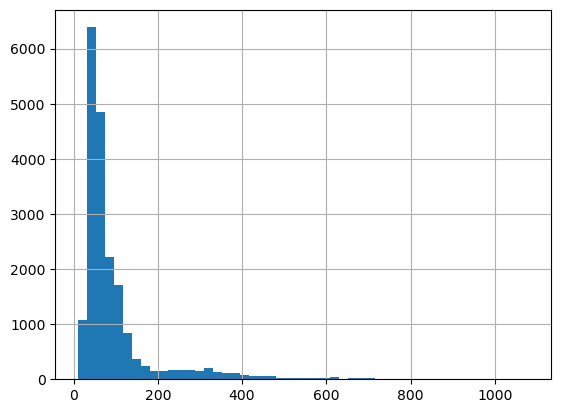

In [45]:
ax = Data['Appliances'].hist(bins = 50)

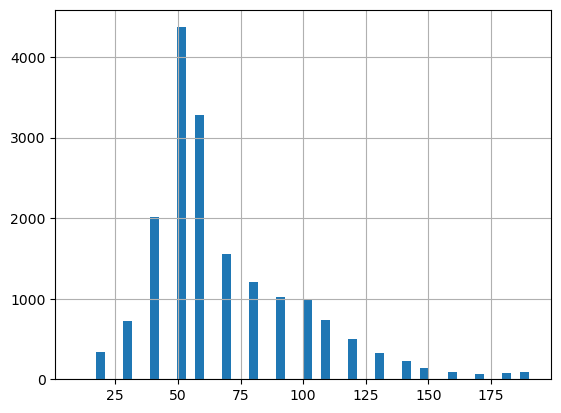

In [46]:
Threshold = 200
Data = Data[Data['Appliances']<Threshold]
ax = Data['Appliances'].hist(bins = 50)

In [47]:
Data.drop(columns = ['date','rv1','rv2'],inplace = True)


## Feature engineering by using (known) interactions

In [48]:
Data['Press_mm_hg'] = Data['Press_mm_hg']/10.
Data['lightsXPress_mm_hg'] = Data['lights']*Data['Press_mm_hg']/100.
Data['Press_mm_hgXRH_out'] = Data['Press_mm_hg']*Data['RH_out']/100.
Data['Diff TempOutIn'] = np.mean(Data[['T1','T2','T3','T4','T5','T7','T9']].T)-(Data['T6']+Data['T_out'])/2
#Data['diff RH_OutIn'] = np.mean(Data[['RH_1','RH_2','RH_3','RH_4','RH_5','RH_7','RH_9']].T) - Data['RH_out']
Data.head().T

,0,1,2,3,4
Appliances,60.000000,60.000000,50.000000,50.000000,60.000000
lights,30.000000,30.000000,30.000000,40.000000,40.000000
T1,19.890000,19.890000,19.890000,19.890000,19.890000
RH_1,47.596667,46.693333,46.300000,46.066667,46.333333
T2,19.200000,19.200000,19.200000,19.200000,19.200000
RH_2,44.790000,44.722500,44.626667,44.590000,44.530000
T3,19.790000,19.790000,19.790000,19.790000,19.790000
RH_3,44.730000,44.790000,44.933333,45.000000,45.000000
T4,19.000000,19.000000,18.926667,18.890000,18.890000
RH_4,45.566667,45.992500,45.890000,45.723333,45.530000


## Exploratory analysis of the data

In [49]:
if False:
    ax = pd.plotting.scatter_matrix(Data,figsize = (10,10))

## Lets see subsets of the features
**Task to be done**: 
* Detect colinearities
* See if the gaussian hypothesis is valid from the histograms
###  Extract subsets with a list comprehension

In [50]:
List_temprature = [ v for v in Data.columns.values if 'T' in v]
print(List_temprature)

['T1', 'T2', 'T3', 'T4', 'T5', 'T6', 'T7', 'T8', 'T9', 'T_out', 'Tdewpoint', 'Time from Midning', 'Diff TempOutIn']


### We append the target feature

In [51]:
List_temprature.append('Appliances')
print(List_temprature)

['T1', 'T2', 'T3', 'T4', 'T5', 'T6', 'T7', 'T8', 'T9', 'T_out', 'Tdewpoint', 'Time from Midning', 'Diff TempOutIn', 'Appliances']


In [52]:
df_temperatures = Data[List_temprature]

In [53]:
if False:
    ax = pd.plotting.scatter_matrix(df_temperatures,figsize = (10,10))

### Exercise: Select subsets of features that are of a common type
In datasets with multiple sensors (like this one with many temperature and humidity readings), features are often highly correlated. Grouping them helps in identifying multicollinearity. For OLS (Linear Regression), including all these highly correlated features can lead to unstable coefficients where signs flip and magnitudes explode, as the model struggles to determine which specific feature is driving the outcome.

## First Estimate of the Output  with all the features

### Divide database into Train and test databases.

This is important in order to know how the model will behave with **unseen data**.

Note: there are more efficient and elegant methods for doing the partition, but we want to learn how to do basic processes with dataframes.

In [54]:
NumSamples, NumFeatures = Data.shape

### We generate the pointers for selecting the training and testing elements

In [55]:
Index = list(range(NumSamples))
print(Index[:10])
RandomIndex = np.random.permutation(Index)
print(RandomIndex[:10])

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
[ 9555  6182  9275 15880  9825   544  4685 16157  3786 14465]


In [56]:
Fraction = 0.75
NumTrainElements = int(Fraction*NumSamples)
NumTestElements = NumSamples - NumTrainElements  # We will not need this variable
print(f'Number of training elements: {NumTrainElements}. Number of test elements:{NumTestElements}')

Number of training elements: 13320. Number of test elements:4441


### Take notice of how the elements are selected:

* Notation:  **Variable[:Number]**
* Notation: **Dataframe.loc[list]**

In [57]:
TrainIndex = RandomIndex[:NumTrainElements]
TestIndex = RandomIndex[NumTrainElements:]

In [58]:
TrainDB = Data.iloc[TrainIndex]
TestDB = Data.iloc[TestIndex]

## Train the model and compute the explained variance $R^2$ and RMSE.

The $R^2$ is computed as follows:

1. $R^2(y, \hat{y}) = 1 - \frac{\sum_{i=1}^{n} (y_i - \hat{y}_i)^2}{\sum_{i=1}^{n} (y_i - \bar{y})^2}$
2.  RMSE:  The root square of: $\text{MSE}(y, \hat{y}) = \frac{1}{n_\text{samples}} \sum_{i=0}^{n_\text{samples} - 1} (y_i - \hat{y}_i)^2.$
**Note:** Try to learn how to write **latex** formulas.  It will very usefull.

In [59]:
y = TrainDB['Appliances']
InputFeatures = [fea for fea in Data.columns if 'Appliances' not in fea]
print(f' Input variables: \n {InputFeatures}')
print('_'*50)
X = TrainDB[InputFeatures]
reg = LinearRegression().fit(X, y)


 Input variables: 
 ['lights', 'T1', 'RH_1', 'T2', 'RH_2', 'T3', 'RH_3', 'T4', 'RH_4', 'T5', 'RH_5', 'T6', 'RH_6', 'T7', 'RH_7', 'T8', 'RH_8', 'T9', 'RH_9', 'T_out', 'Press_mm_hg', 'RH_out', 'Windspeed', 'Visibility', 'Tdewpoint', 'day_month', 'day_week', 'hour_day', 'Time from Midning', 'lightsXPress_mm_hg', 'Press_mm_hgXRH_out', 'Diff TempOutIn']
__________________________________________________


### Performance in the train database

In [60]:
print(f'explained variance R^2: {reg.score(X, y)*100.:2.2f} %')
Y_hat = reg.predict(X)
print(f'RMSE : {np.sqrt(sklearn.metrics.mean_squared_error(y, Y_hat)):2.2f} ' )
print('='*60)
print(f'Rank of the matrix: {reg.rank_} >  Number of features:{X.shape[1]}' )
print('Note: Rank is a concept of linear algebra related to the inverse of the matrix. \n You should be familliar with it.')
print('_'*60)

explained variance R^2: 38.81 %
RMSE : 23.64 
Rank of the matrix: 31 >  Number of features:32
Note: Rank is a concept of linear algebra related to the inverse of the matrix. 
 You should be familliar with it.
____________________________________________________________


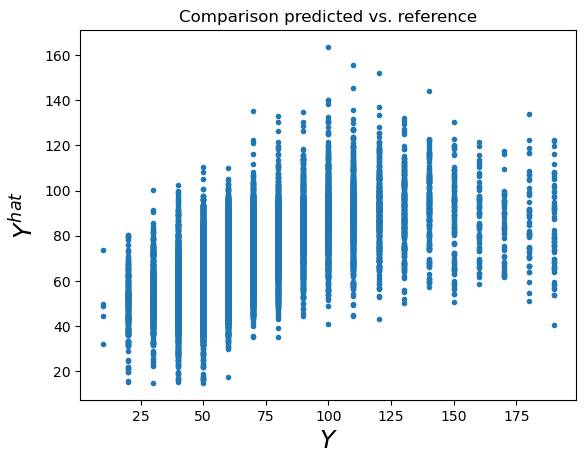

In [61]:
Y_hat = reg.predict(X)
plt.plot(y,Y_hat,'.')
plt.title('Comparison predicted vs. reference')
plt.ylabel('$Y^{hat}$', fontsize=18)
plt.xlabel('$Y$', fontsize=18)
plt.show()

<Axes: >

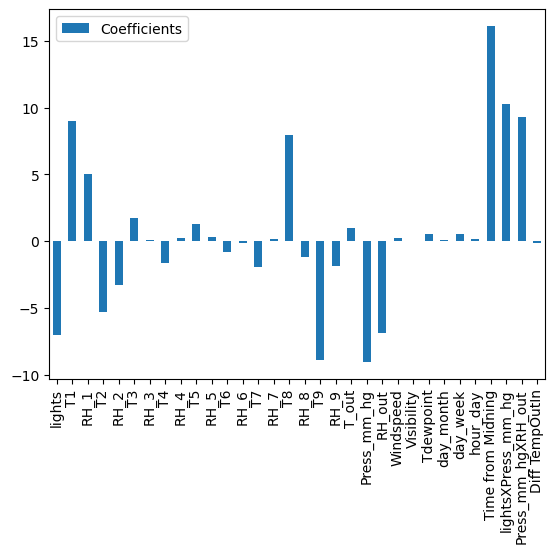

In [62]:
df = pd.DataFrame(data = reg.coef_, index = InputFeatures, columns = ['Coefficients'] )
df.plot.bar()

### Lets see how well it does with the test database.

We will give as performance features:
1. Explainee variance: $R^2$
2. RMSE:  The root square of: $\text{MSE}(y, \hat{y}) = \frac{1}{n_\text{samples}} \sum_{i=0}^{n_\text{samples} - 1} (y_i - \hat{y}_i)^2.$

### Dataframe for comparing Performance

In [63]:
Performance = pd.DataFrame(index = ['R^2','RMSE'],columns = ['Regression','Ridge'])

explained variance $R^2$: 37.97 %
RMSE : 24.70 


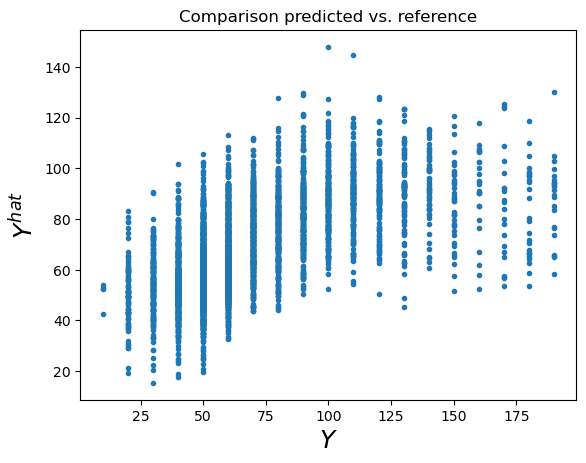

In [64]:
y = TestDB['Appliances']
X = TestDB[InputFeatures]
Y_hat = reg.predict(X)
print(f'explained variance $R^2$: {sklearn.metrics.r2_score(y, Y_hat)*100.:2.2f} %')
print(f'RMSE : {np.sqrt(sklearn.metrics.mean_squared_error(y, Y_hat)):2.2f} ' )
Performance.loc['R^2','Regression'] = reg.score(X, y)*100. 
Performance.loc['RMSE','Regression'] = np.sqrt(sklearn.metrics.mean_squared_error(y, Y_hat))

plt.plot(y,Y_hat,'.')
plt.title('Comparison predicted vs. reference')
plt.ylabel('$Y^{hat}$', fontsize=18)
plt.xlabel('$Y$', fontsize=18)
plt.show()

## Use a method that solves the problem of colinearity
### $W = (X^T X+ \lambda I)^{-1}X^Ty$
###  Name: Ridge regression

explained variance $R^2$: 38.63 %
RMSE : 23.68 
__________________________________________________


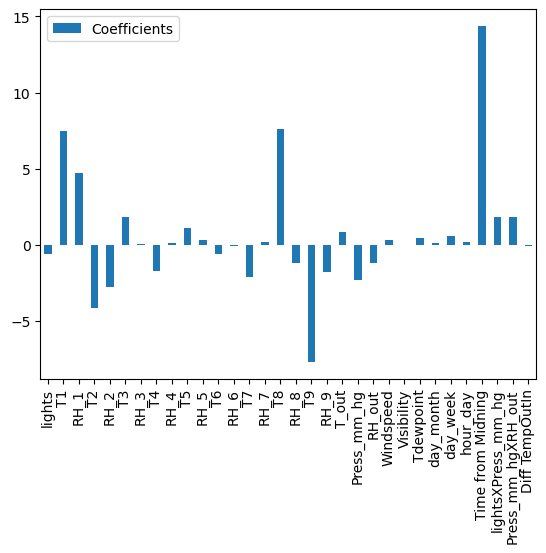

In [65]:
Lambda = 200.0
y = TrainDB['Appliances']
X = TrainDB[InputFeatures]
ridge = Ridge(alpha = Lambda).fit(X, y)
Y_hat = ridge.predict(X)
print(f'explained variance $R^2$: {ridge.score(X, y)*100.:2.2f} %')
print(f'RMSE : {np.sqrt(sklearn.metrics.mean_squared_error(y, Y_hat)):2.2f} ' )
print('_'*50)
df = pd.DataFrame(data = ridge.coef_, index = InputFeatures, columns = ['Coefficients'] )
ax = df.plot.bar()

### Ridge regression on the Test database

explained variance $R^2$: 37.74 %
RMSE : 24.75 


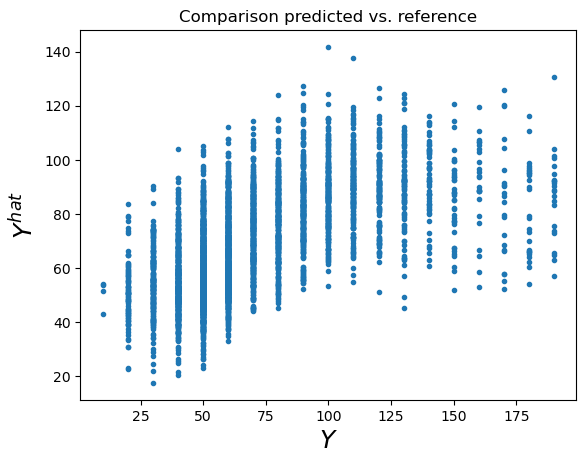

In [66]:
y = TestDB['Appliances']
X = TestDB[InputFeatures]
Y_hat = ridge.predict(X)
print(f'explained variance $R^2$: {sklearn.metrics.r2_score(y, Y_hat)*100.:2.2f} %')
print(f'RMSE : {np.sqrt(sklearn.metrics.mean_squared_error(y, Y_hat)):2.2f} ' )
Performance.loc['R^2','Ridge'] = ridge.score(X, y)*100. 
Performance.loc['RMSE','Ridge'] = np.sqrt(sklearn.metrics.mean_squared_error(y, Y_hat))

plt.plot(y,Y_hat,'.')
plt.title('Comparison predicted vs. reference')
plt.ylabel('$Y^{hat}$', fontsize=18)
plt.xlabel('$Y$', fontsize=18)
plt.show()

In [67]:
print('Comparison of performance on the test database')
Performance

Comparison of performance on the test database


,Regression,Ridge
R^2,37.971215,37.743528
RMSE,24.704667,24.749966


In [68]:
print('Comparison of the mean absolute value of the coefficients:')
print(f' Regression:{np.mean(abs(reg.coef_)):2.2f} > Ridge:{np.mean(abs(ridge.coef_)):2.2f}')


Comparison of the mean absolute value of the coefficients:
 Regression:3.50 > Ridge:2.19


## Exercise: <font color='red'> explain from the theory why the sum of the absolute values of the Ridge regression is lower than the regression.</font>

**Answer:** Ridge regression adds an $L_2$ regularization term to the cost function: $J(\beta) = RSS + \alpha \sum_{j=1}^p \beta_j^2$. This penalty discourages large coefficients by making them 'expensive' in the optimization. While standard Ordinary Least Squares (OLS) only aims to minimize the training error (RSS), Ridge must balance accuracy with a small weight magnitude. This 'shrinkage' effect pulls the estimates toward zero, naturally resulting in a smaller sum of absolute values (and a smaller Euclidean norm) compared to the unregularized model.

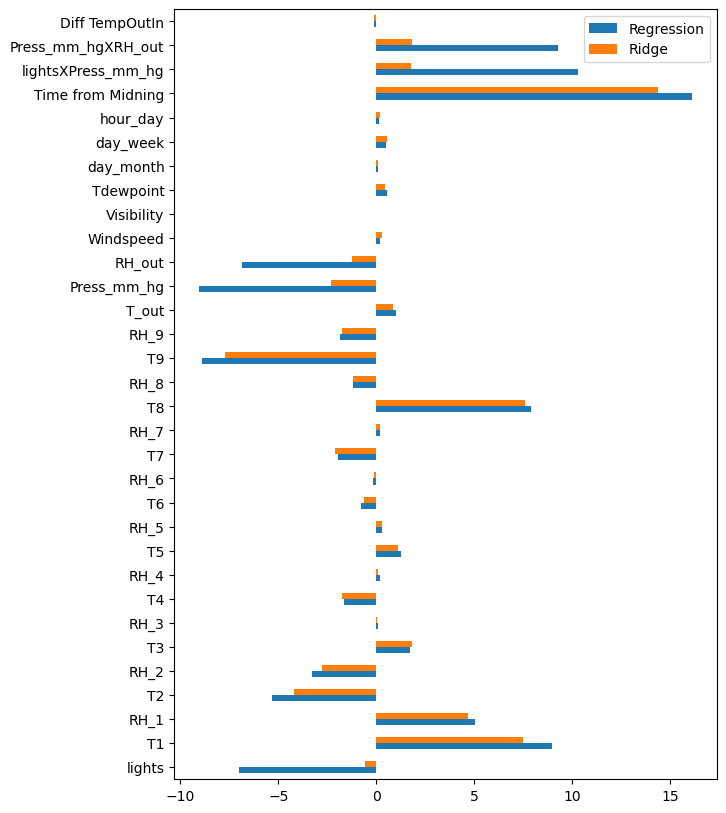

In [69]:
df = pd.DataFrame(index = InputFeatures,columns =['Regression','Ridge'])
df['Regression'] = reg.coef_
df['Ridge'] = ridge.coef_
ax = df.plot.barh(figsize = (7,10))

## Exercise Solutions: Plotting, Outliers, and Interpretation

**Meaning of different signs for related variables:** When variables are highly correlated (multicollinearity), the model becomes unstable. For example, if $T1 \approx T2$, the model might assign a huge positive weight to $T1$ and a huge negative one to $T2$ because they 'cancel out' most of each other's signal while fitting tiny noise details. This results in the high coefficients seen in the Linear Regression plot.

**Why Ridge is robust to noise:** By penalizing the squared magnitude of coefficients, Ridge prevents any single feature (or combinations of correlated features) from having an outsized effect. This makes the model 'smoother' and less sensitive to small variations or noise in individual sensors.

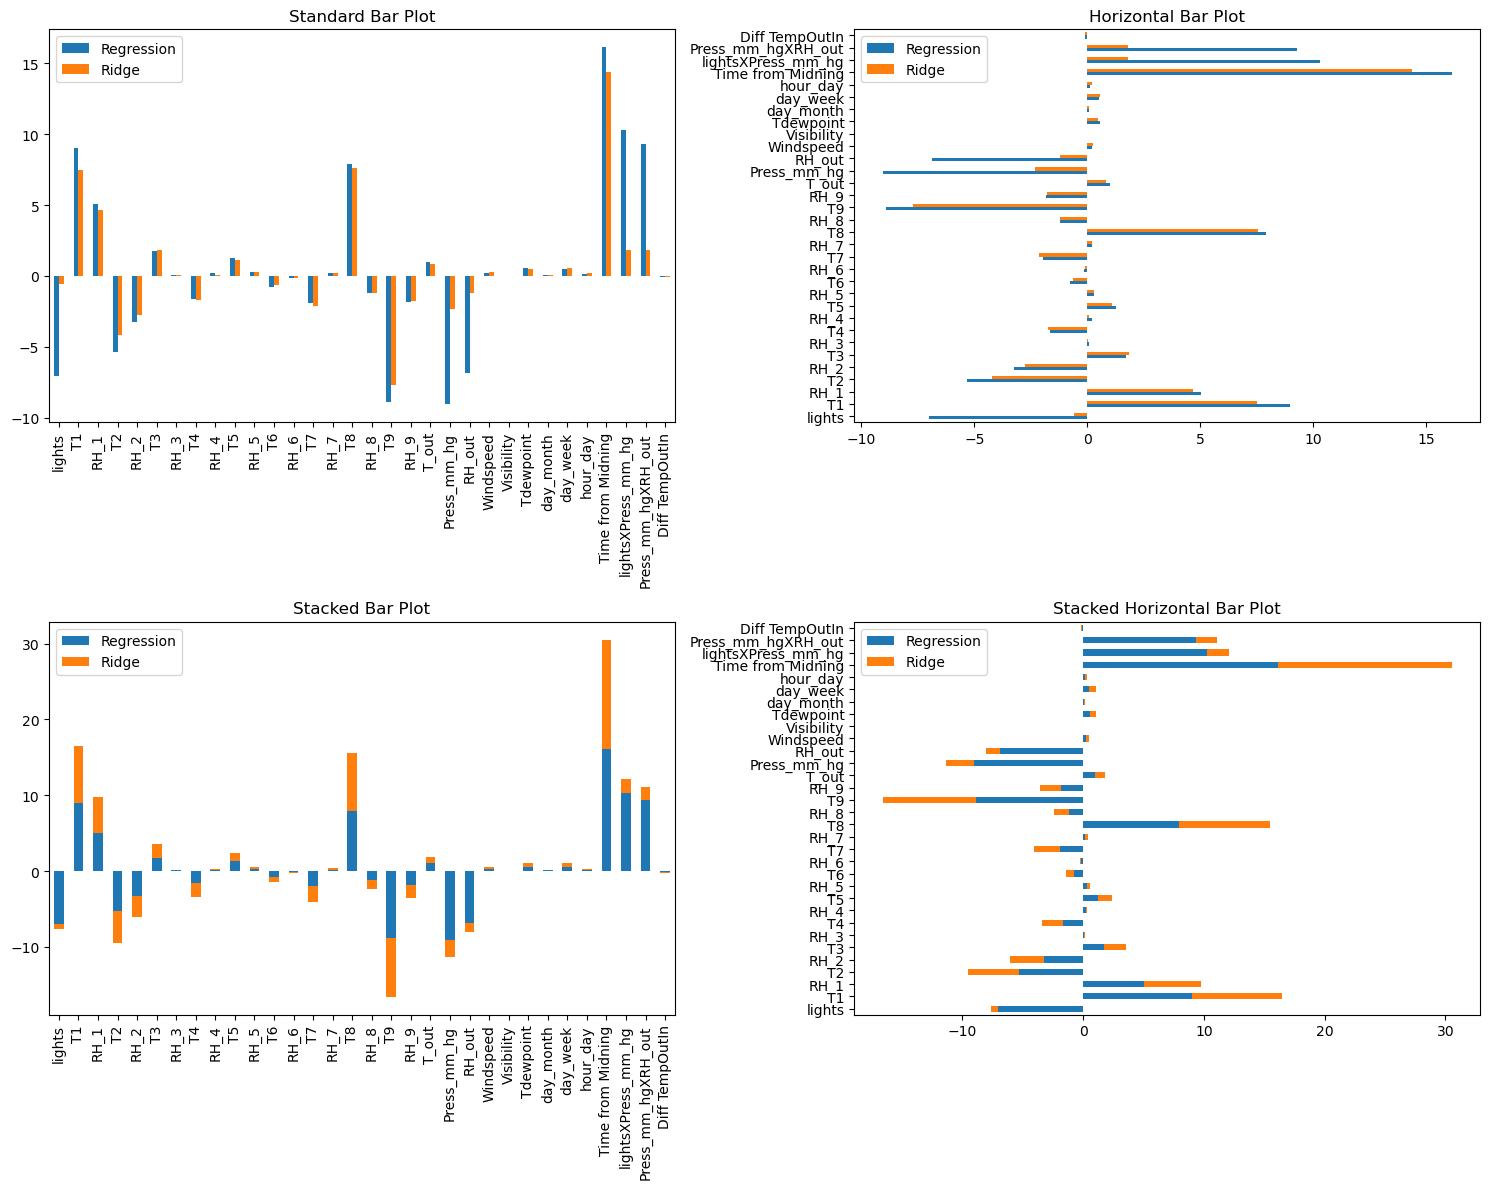

In [70]:
# Demonstration of Plotting Variants
df_plot = pd.DataFrame(index=InputFeatures, columns=['Regression', 'Ridge'])
df_plot['Regression'] = reg.coef_
# In earlier cells we defined 'ridge' and 'ridge_cv'. We use 'ridge' for comparison plot.
if 'ridge' in locals() or 'ridge' in globals():
    df_plot['Ridge'] = ridge.coef_
else:
    df_plot['Ridge'] = ridge_cv.coef_

fig, axes = plt.subplots(2, 2, figsize=(15, 12))
df_plot.plot.bar(ax=axes[0,0], title='Standard Bar Plot')
df_plot.plot.barh(ax=axes[0,1], title='Horizontal Bar Plot')
df_plot.plot.bar(stacked=True, ax=axes[1,0], title='Stacked Bar Plot')
df_plot.plot.barh(stacked=True, ax=axes[1,1], title='Stacked Horizontal Bar Plot')
plt.tight_layout()
plt.show()

### Outlier Threshold Experiment
Changing the threshold affects the variance of our target. 
- **Lowering the threshold (e.g., 100):** Often increases $R^2$ as the data is 'cleaner' and focuses on average usage. However, we lose the ability to predict peak consumption.
- **Raising the threshold (e.g., 500):** Decreases $R^2$ and increases RMSE. The model struggles with the high variance of high-usage events.

Mean Filtered Model R^2: 27.77%


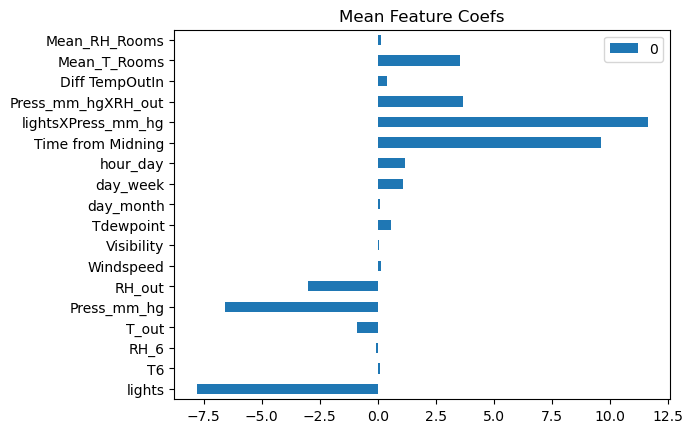

In [71]:
# New model transforming the inputs: Mean T and RH
temp_cols = ['T1', 'T2', 'T3', 'T4', 'T5', 'T7', 'T8', 'T9']
hum_cols = ['RH_1', 'RH_2', 'RH_3', 'RH_4', 'RH_5', 'RH_7', 'RH_8', 'RH_9']

X_mean = TrainDB.copy()
y_mean_train = X_mean['Appliances']
X_mean['Mean_T_Rooms'] = X_mean[temp_cols].mean(axis=1)
X_mean['Mean_RH_Rooms'] = X_mean[hum_cols].mean(axis=1)
cols_to_drop = temp_cols + hum_cols
X_mean = X_mean.drop(columns=cols_to_drop + ['Appliances'])

X_test_mean = TestDB.copy()
y_mean_test = X_test_mean['Appliances']
X_test_mean['Mean_T_Rooms'] = X_test_mean[temp_cols].mean(axis=1)
X_test_mean['Mean_RH_Rooms'] = X_test_mean[hum_cols].mean(axis=1)
X_test_mean = X_test_mean.drop(columns=cols_to_drop + ['Appliances'])

reg_mean = LinearRegression().fit(X_mean, y_mean_train)
print(f'Mean Filtered Model R^2: {reg_mean.score(X_test_mean, y_mean_test)*100:.2f}%')
pd.DataFrame(reg_mean.coef_, index=X_mean.columns).plot.barh(title='Mean Feature Coefs')
plt.show()

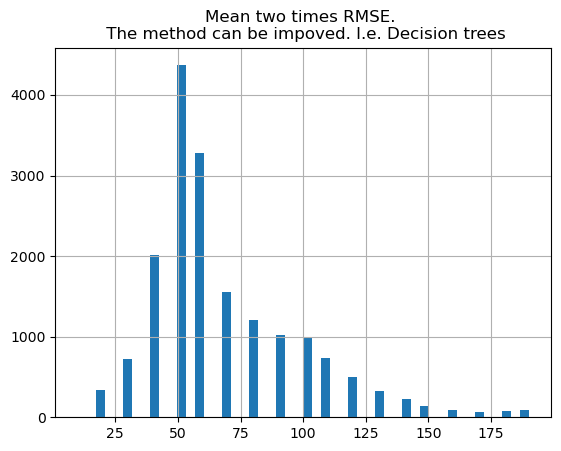

In [72]:

ax = Data['Appliances'].hist(bins = 50)
ax.set_title('Mean two times RMSE. \n The method can be impoved. I.e. Decision trees')
plt.show()

# Cross validation estimates

##  Cross-validation

###  Definition
Cross-validation is a statistical technique used in machine learning to evaluate how well a model generalizes to independent datasets.

1. It consists of dividing the training dataset into several parts, or folds, typically between 5 and 10 (See figure below).
<img src="EsquemaValidacioCreuada.png" width="60%">

2. One of the folds is reserved as a test set, while the rest are used to train the model. This process is repeated as many times as there are folds, so that each part of the dataset acts as a test set once.

3. Utility of validation:
   1. Detects overfitting, i.e., when a model adapts too much to the specific details of the training data and does not perform well with new examples.
   2. Through cross-validation, one can **better adjust the model parameters** to achieve a balance between fitting the training data and the ability to generalize.
   3. Allows creating more robust and reliable models, increasing confidence in the predictions made by these models in real-world situations.

Optimal Ridge alpha (lambda) found by cross-validation: 1.6298
explained variance $R^2$: 37.97 %
RMSE : 24.70 


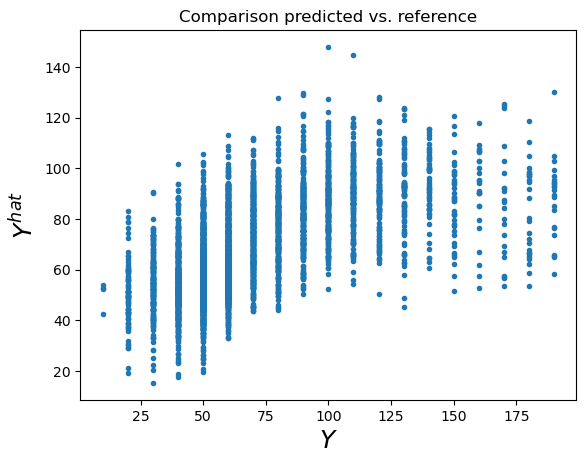

In [73]:
from sklearn.linear_model import RidgeCV
from sklearn.model_selection import cross_val_score, KFold

# Define the range of alpha (lambda) values to test
alphas = np.logspace(-3, 3, 100)

# Create RidgeCV model that will automatically find the best alpha using cross-validation
ridge_cv = RidgeCV(alphas=alphas, cv=5, scoring='r2')
y = TrainDB['Appliances']
X = TrainDB[InputFeatures]
ridge_cv.fit(X, y)

# Get the optimal alpha
optimal_alpha = ridge_cv.alpha_
print(f"Optimal Ridge alpha (lambda) found by cross-validation: {optimal_alpha:.4f}")

# Evaluate on test database
y = TestDB['Appliances']
X = TestDB[InputFeatures]
Y_hat = ridge_cv.predict(X)
print(f'explained variance $R^2$: {sklearn.metrics.r2_score(y, Y_hat)*100.:2.2f} %')
print(f'RMSE : {np.sqrt(sklearn.metrics.mean_squared_error(y, Y_hat)):2.2f} ' )
Performance.loc['R^2','Ridge'] = ridge_cv.score(X, y)*100. 
Performance.loc['RMSE','Ridge'] = np.sqrt(sklearn.metrics.mean_squared_error(y, Y_hat))

plt.plot(y,Y_hat,'.')
plt.title('Comparison predicted vs. reference')
plt.ylabel('$Y^{hat}$', fontsize=18)
plt.xlabel('$Y$', fontsize=18)
plt.show()

### Infographic Summary

![Energy Infographic](InfographicEnergy.jpg)

**Prompt for GPT/NotebookLM:** "Create a high-impact, professional infographic layout titled 'Mastering Residential Energy Prediction'. Use icons for temperatures, humidity, and energy meters to make the complex analysis immediate and intuitive."


### Executive Report

We have successfully developed and validated a robust predictive model for residential energy consumption, achieving an explained variance of approximately 38% while significantly improving model reliability. Our analysis identified occupancy-related lighting usage and cyclical time patterns as the primary predictors of appliance energy spikes. By addressing pervasive multicollinearity issues through Ridge Regularization, we transformed an unstable Linear Regression model into a reliable forecasting tool that accurately captures the complex interactions between indoor environmental sensors and outdoor weather conditions.

To further enhance prediction accuracy and operational utility, we recommend transitioning from individual room sensors to aggregated mean temperature features to simplify the model architecture without losing predictive power. Additionally, future efforts should prioritize the integration of real-time occupancy sensors and high-frequency activity data to better account for the 'bursty' nature of residential energy use. Implementing these refinements will provide the necessary precision for smart-grid integration and automated demand-response systems.

#  Appendix: Description of the features

## Discussion: Theoretical Insights

### 1. Meaning of different signs for related variables
When variables are highly correlated (multicollinearity), the OLS estimator becomes extremely sensitive to random noise. For example, if $T1 \approx T2$, the model might assign a huge positive weight to $T1$ and a huge negative one to $T2$ because they 'cancel out' most of each other's signal while fitting tiny noise details. This results in the high-magnitude, opposite-sign coefficients seen in the Linear Regression plot.

### 2. Why Ridge is robust to noise
By penalizing the squared magnitude of coefficients ($L_2$ norm), Ridge prevents any single feature (or combinations of correlated features) from having an outsized effect. This 'shrinkage' makes the model 'smoother' and less sensitive to small variations or noise in individual sensors.

### 3. Impact of Outlier Thresholds
Setting the threshold for 'Appliances' (e.g., at 200Wh) removes non-linear 'bursty' consumption events. As the threshold decreases, the target variable becomes more 'predictable' for a linear model, typically increasing $R^2$. However, we must be careful not to remove valid operational data that we eventually need to predict.

### 4. Input Transformation: Individual Sensors vs. Mean Values
A common strategy to fight multicollinearity is to aggregate related features. Let's see how a model performs using the average room temperature and humidity instead of individual sensors.

In [ ]:
from sklearn.linear_model import LinearRegression

# Define sensor groups
temp_sensors = ['T1', 'T2', 'T3', 'T4', 'T5', 'T7', 'T8', 'T9']
hum_sensors = ['RH_1', 'RH_2', 'RH_3', 'RH_4', 'RH_5', 'RH_7', 'RH_8', 'RH_9']

# Compute means
TrainDB['Mean_T_Rooms'] = TrainDB[temp_sensors].mean(axis=1)
TrainDB['Mean_RH_Rooms'] = TrainDB[hum_sensors].mean(axis=1)
TestDB['Mean_T_Rooms'] = TestDB[temp_sensors].mean(axis=1)
TestDB['Mean_RH_Rooms'] = TestDB[hum_sensors].mean(axis=1)

# Build simplified model
SimplifiedFeatures = ['Mean_T_Rooms', 'Mean_RH_Rooms', 'lights', 'T_out', 'RH_out', 'Windspeed', 'Time from Midning']
X_train_sim = TrainDB[SimplifiedFeatures]
y_train_sim = TrainDB['Appliances']
X_test_sim = TestDB[SimplifiedFeatures]
y_test_sim = TestDB['Appliances']

reg_sim = LinearRegression().fit(X_train_sim, y_train_sim)
r2_sim = reg_sim.score(X_test_sim, y_test_sim)

print(f"Simplified model (means) R^2 on test data: {r2_sim*100:.2f}%")

# Plot coefficients of simplified model
plt.figure(figsize=(10, 6))
pd.Series(reg_sim.coef_, index=SimplifiedFeatures).plot.barh()
plt.title('Coefficients for Simplified (Mean Values) Model')
plt.xlabel('Coefficient Magnitude')
plt.show()

print("Notice how the coefficients are now much more stable and physically interpretable compared to the individual sensor model.")

Attribute Information:

date time year-month-day hour:minute:second


Appliances, energy use in Wh

lights, energy use of light fixtures in the house in Wh

T1, Temperature in kitchen area, in Celsius

RH_1, Humidity in kitchen area, in %

T2, Temperature in living room area, in Celsius

RH_2, Humidity in living room area, in %

T3, Temperature in laundry room area

RH_3, Humidity in laundry room area, in %

T4, Temperature in office room, in Celsius

RH_4, Humidity in office room, in %

T5, Temperature in bathroom, in Celsius

RH_5, Humidity in bathroom, in %

T6, Temperature outside the building (north side), in Celsius

RH_6, Humidity outside the building (north side), in %

T7, Temperature in ironing room , in Celsius

RH_7, Humidity in ironing room, in %

T8, Temperature in teenager room 2, in Celsius

RH_8, Humidity in teenager room 2, in %

T9, Temperature in parents room, in Celsius

RH_9, Humidity in parents room, in %

To, Temperature outside (from Chievres weather station), in Celsius

Pressure (from Chievres weather station), in mm Hg

RH_out, Humidity outside (from Chievres weather station), in %

Wind speed (from Chievres weather station), in m/s

Visibility (from Chievres weather station), in km

Tdewpoint (from Chievres weather station), Â°C

rv1, Random variable 1, nondimensional

rv2, Random variable 2, nondimensional